## Exploratory Data Analysis 

### Imports and loading data 

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

os.makedirs('artifacts', exist_ok=True)

In [2]:
df = pd.read_csv('Wildfire_Dataset.csv', parse_dates=['datetime'])

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nDtypes:\n', df.dtypes)
df.head()

Shape: (9509925, 19)

Columns: ['latitude', 'longitude', 'datetime', 'Wildfire', 'pr', 'rmax', 'rmin', 'sph', 'srad', 'tmmn', 'tmmx', 'vs', 'bi', 'fm100', 'fm1000', 'erc', 'etr', 'pet', 'vpd']

Dtypes:
 latitude            float64
longitude           float64
datetime     datetime64[ns]
Wildfire             object
pr                  float64
rmax                float64
rmin                float64
sph                 float64
srad                float64
tmmn                float64
tmmx                float64
vs                  float64
bi                  float64
fm100               float64
fm1000              float64
erc                 float64
etr                 float64
pet                 float64
vpd                 float64
dtype: object


,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
0,48.128431,-97.276685,2018-08-15,No,0.0,78.6,14.9,0.00582,272.6,282.0,301.6,3.0,40.0,10.2,12.2,54.0,7.5,5.5,1.59
1,48.128431,-97.276685,2018-08-16,No,0.0,80.4,13.9,0.00676,264.0,283.9,304.9,3.0,40.0,9.7,12.0,56.0,8.2,5.9,1.93
2,48.128431,-97.276685,2018-08-17,No,0.0,70.9,20.4,0.00672,265.6,285.8,300.7,3.1,40.0,9.2,11.9,56.0,7.2,5.3,1.51
3,48.128431,-97.276685,2018-08-18,No,5.0,65.2,19.4,0.00756,261.4,289.0,303.3,5.1,0.0,9.9,12.0,40.0,10.0,6.9,1.85
4,48.128431,-97.276685,2018-08-19,No,0.0,100.0,42.2,0.00895,166.8,283.8,296.5,4.7,41.0,11.8,12.1,47.0,4.6,3.4,0.66


### Looking at the data structure

In [3]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nBasic statistics:')
df.describe()

Missing values per column:
latitude     0
longitude    0
datetime     0
Wildfire     0
pr           0
rmax         0
rmin         0
sph          0
srad         0
tmmn         0
tmmx         0
vs           0
bi           0
fm100        0
fm1000       0
erc          0
etr          0
pet          0
vpd          0
dtype: int64

Basic statistics:


,latitude,longitude,datetime,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
count,9.509925e+06,9.509925e+06,9509925,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06
mean,3.914362e+01,-1.064347e+02,2018-06-13 17:01:47.688549120,9.036891e+01,1.645754e+02,1.220707e+02,8.864304e+01,3.091587e+02,3.682137e+02,3.821415e+02,9.239142e+01,1.221668e+02,1.013892e+02,1.030986e+02,1.320922e+02,9.425599e+01,9.275527e+01,8.976546e+01
min,2.526027e+01,-1.244370e+02,2013-12-31 00:00:00,0.000000e+00,5.000000e+00,1.000000e+00,1.300000e-04,0.000000e+00,2.309000e+02,2.419000e+02,3.000000e-01,0.000000e+00,1.100000e+00,2.100000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.468867e+01,-1.183439e+02,2015-11-23 00:00:00,0.000000e+00,6.180000e+01,1.930000e+01,3.600000e-03,1.472000e+02,2.749000e+02,2.879000e+02,2.600000e+00,1.900000e+01,8.700000e+00,1.030000e+01,2.500000e+01,3.200000e+00,2.300000e+00,4.700000e-01
50%,3.853161e+01,-1.109258e+02,2018-01-30 00:00:00,0.000000e+00,8.000000e+01,3.080000e+01,5.520000e-03,2.277000e+02,2.811000e+02,2.955000e+02,3.400000e+00,3.400000e+01,1.290000e+01,1.480000e+01,3.900000e+01,5.400000e+00,4.100000e+00,9.200000e-01
75%,4.367004e+01,-9.541990e+01,2020-09-07 00:00:00,0.000000e+00,9.520000e+01,4.550000e+01,7.790000e-03,3.001000e+02,2.864000e+02,3.019000e+02,4.600000e+00,5.000000e+01,1.660000e+01,1.840000e+01,6.100000e+01,7.700000e+00,5.800000e+00,1.580000e+00
max,4.899873e+01,-6.701250e+01,2025-04-13 00:00:00,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04
std,5.267332e+00,1.456924e+01,NaN,1.701836e+03,1.698086e+03,1.700272e+03,1.701914e+03,1.692717e+03,1.687376e+03,1.686659e+03,1.701719e+03,1.700336e+03,1.701257e+03,1.701169e+03,1.699822e+03,1.701624e+03,1.701701e+03,1.701856e+03


In [4]:
rows_per_location = df.groupby(['latitude', 'longitude']).size()
print('Rows per location (multiples of 75 expected):')
print(rows_per_location.value_counts().head(10))

Rows per location (multiples of 75 expected):
75     13877
150     6218
225     3775
300     2786
375     2072
450     2010
525     1639
600     1485
675     1190
750     1070
Name: count, dtype: int64


### checking the sentinel value - note GRIDMET encodes missing readings as 32767.0

In [5]:
FILL_VALUE = 32767.0
FEATURES = ['pr', 'rmax', 'rmin', 'sph', 'srad', 'tmmn', 'tmmx',
            'vs', 'bi', 'fm100', 'fm1000', 'erc', 'etr', 'pet', 'vpd']

sentinel_rows = (df[FEATURES] == FILL_VALUE).any(axis=1).sum()
print(f'Rows containing sentinel value {FILL_VALUE}: {sentinel_rows:,}')
print(f'That is {sentinel_rows / len(df) * 100:.2f}% of all rows')
print('\nSentinel counts per feature:')
print((df[FEATURES] == FILL_VALUE).sum())

Rows containing sentinel value 32767.0: 25,725
That is 0.27% of all rows

Sentinel counts per feature:
pr        25725
rmax      25725
rmin      25725
sph       25725
srad      25725
tmmn      25725
tmmx      25725
vs        25725
bi        25725
fm100     25725
fm1000    25725
erc       25725
etr       25725
pet       25725
vpd       25725
dtype: int64


# looking into class balance 

In [6]:
sample_rows = []
for (lat, lon), loc_df in df.groupby(['latitude', 'longitude']):
    loc_df = loc_df.sort_values('datetime').reset_index(drop=True)
    for start in range(0, len(loc_df) - 75 + 1, 75):
        window = loc_df.iloc[start:start + 75]
        if len(window) == 75:
            row = window.iloc[0].copy()
            row['Wildfire'] = 'Yes' if (window['Wildfire'] == 'Yes').any() else 'No'
            sample_rows.append(row)

samples = pd.DataFrame(sample_rows).reset_index(drop=True)
print('Total samples:', len(samples))

class_counts = samples['Wildfire'].value_counts()
print('\nSamples per class:')
print(class_counts)
print(f'\nClass balance: {class_counts["Yes"] / len(samples) * 100:.1f}% wildfire, '
      f'{class_counts["No"] / len(samples) * 100:.1f}% non-wildfire')

Total samples: 126799

Samples per class:
Wildfire
No     93515
Yes    33284
Name: count, dtype: int64

Class balance: 26.2% wildfire, 73.8% non-wildfire


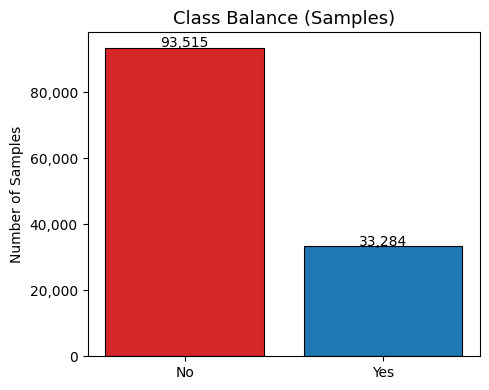

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    class_counts.index,
    class_counts.values,
    color=['#d62728', '#1f77b4'],
    edgecolor='black',
    linewidth=0.8
)
ax.set_title('Class Balance (Samples)', fontsize=13)
ax.set_ylabel('Number of Samples')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (label, count) in enumerate(class_counts.items()):
    ax.text(i, count + 200, f'{count:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('artifacts/class_balance.png', dpi=150)
plt.show()

### setting up the feautures

In [8]:
FEATURE_LABELS = {
    'pr':     'Precipitation',
    'rmax':   'Max Relative Humidity',
    'rmin':   'Min Relative Humidity',
    'sph':    'Specific Humidity',
    'srad':   'Solar Radiation',
    'tmmn':   'Min Temperature (K)',
    'tmmx':   'Max Temperature (K)',
    'vs':     'Wind Speed',
    'bi':     'Burning Index',
    'fm100':  'Fuel Moisture 100hr',
    'fm1000': 'Fuel Moisture 1000hr',
    'erc':    'Energy Release Component',
    'etr':    'Reference ET',
    'pet':    'Potential Evapotranspiration',
    'vpd':    'Vapor Pressure Deficit'
}

### looking at the distribution of features

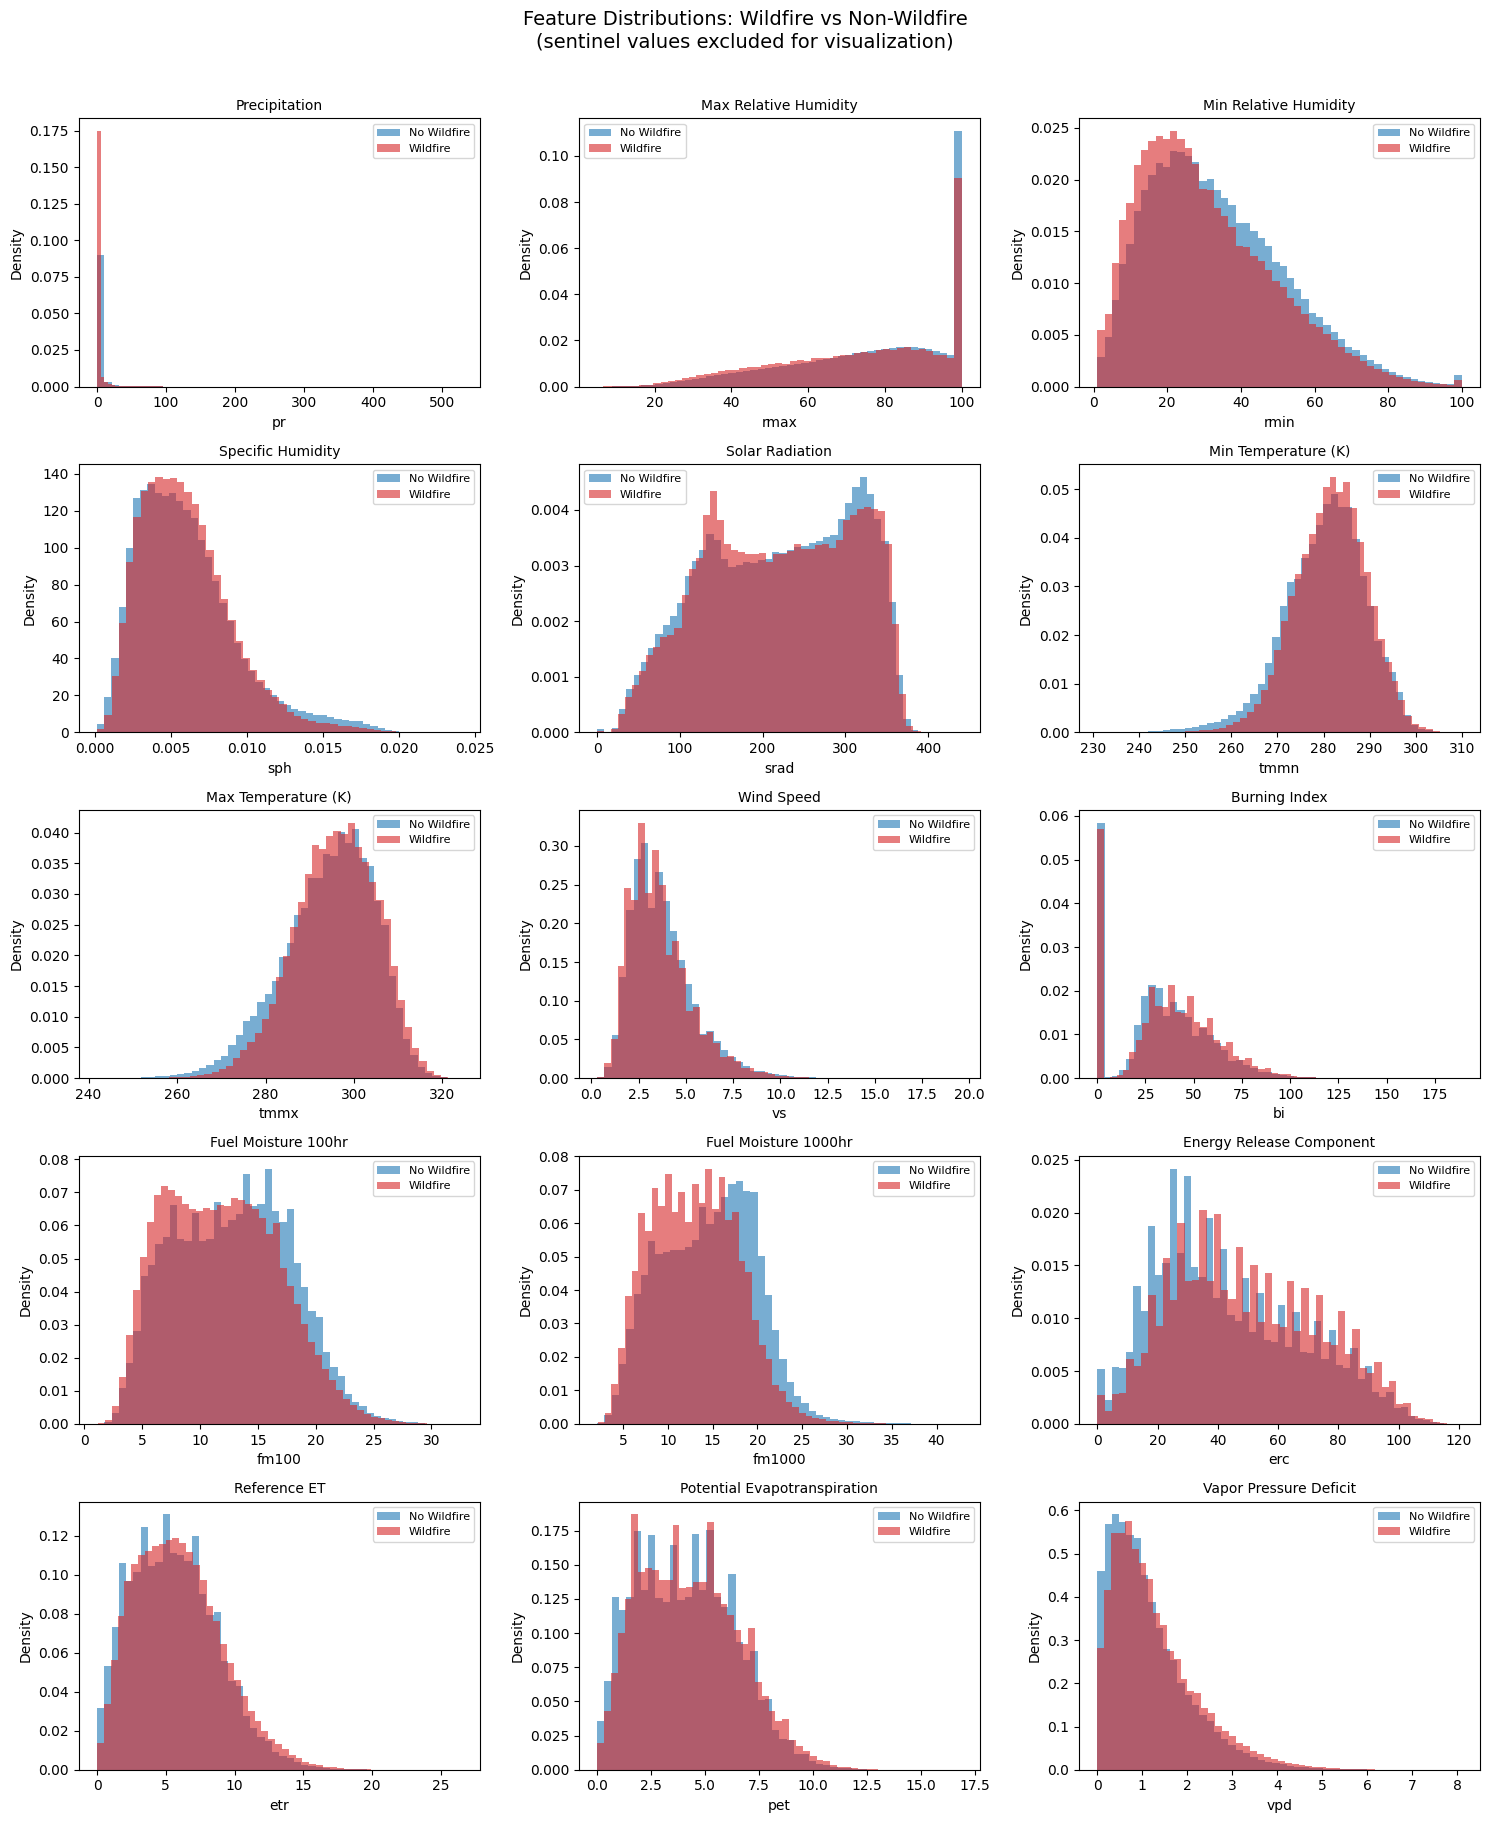

In [9]:
df_plot = df.loc[~(df[FEATURES] == FILL_VALUE).any(axis=1)].copy()

fire = df_plot[df_plot['Wildfire'] == 'Yes']
no_fire = df_plot[df_plot['Wildfire'] == 'No']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(no_fire[feat].dropna(), bins=50, alpha=0.6,
            color='#1f77b4', label='No Wildfire', density=True)
    ax.hist(fire[feat].dropna(), bins=50, alpha=0.6,
            color='#d62728', label='Wildfire', density=True)
    ax.set_title(FEATURE_LABELS[feat], fontsize=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Wildfire vs Non-Wildfire\n(sentinel values excluded for visualization)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('artifacts/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Temporal Patterns Over the 75-Day Window

In [10]:
df_plot = df_plot.sort_values(['latitude', 'longitude', 'datetime'])
df_plot['day_idx'] = df_plot.groupby(['latitude', 'longitude']).cumcount() % 75

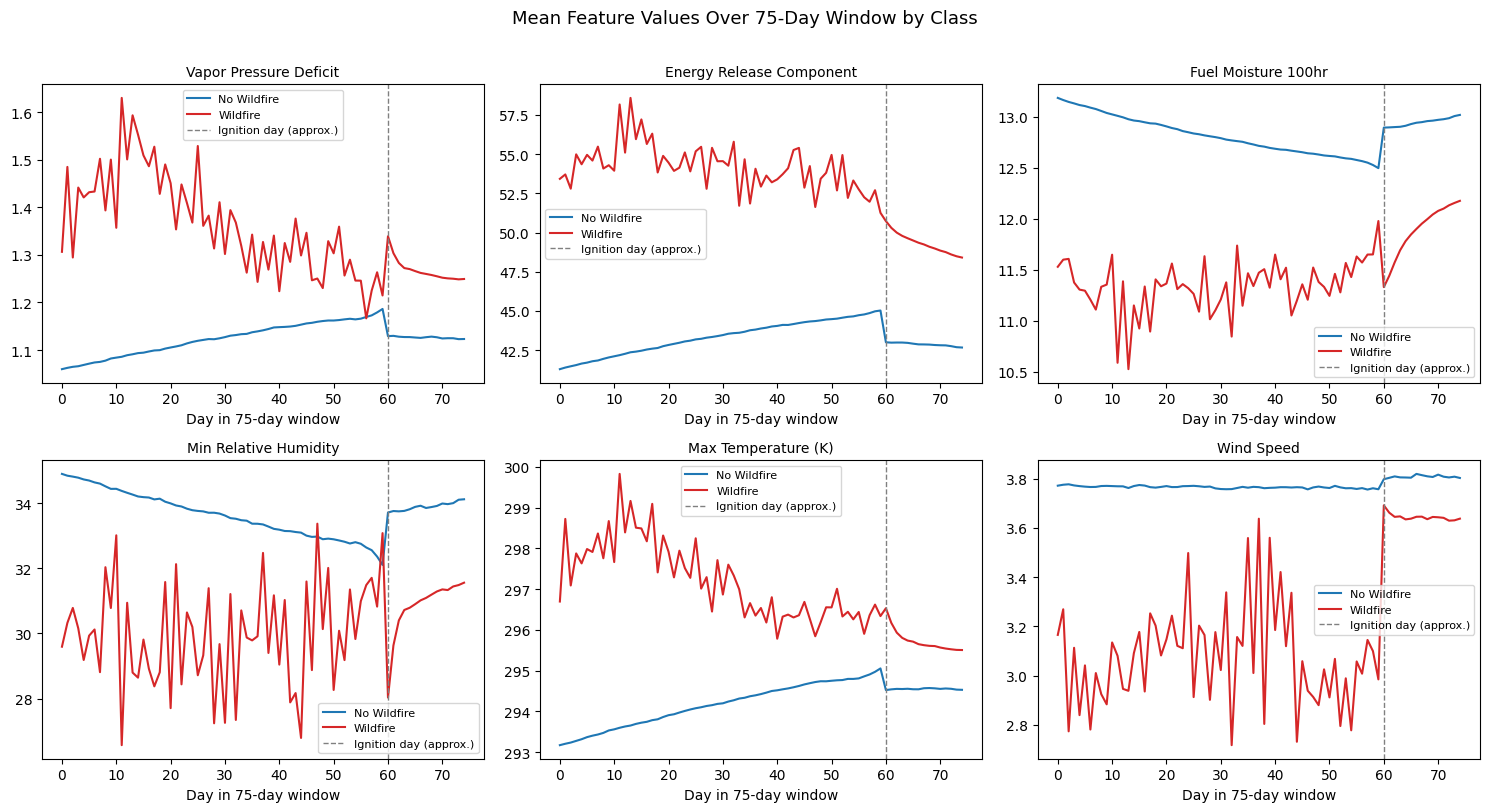

In [11]:
temporal_fire = df_plot[df_plot['Wildfire'] == 'Yes'].groupby('day_idx')[FEATURES].mean()
temporal_no_fire = df_plot[df_plot['Wildfire'] == 'No'].groupby('day_idx')[FEATURES].mean()

TEMPORAL_FEATURES = ['vpd', 'erc', 'fm100', 'rmin', 'tmmx', 'vs']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(TEMPORAL_FEATURES):
    ax = axes[i]
    ax.plot(temporal_no_fire.index, temporal_no_fire[feat],
            color='#1f77b4', label='No Wildfire', linewidth=1.5)
    ax.plot(temporal_fire.index, temporal_fire[feat],
            color='#d62728', label='Wildfire', linewidth=1.5)
    ax.axvline(x=60, color='gray', linestyle='--', linewidth=1,
               label='Ignition day (approx.)')
    ax.set_title(FEATURE_LABELS[feat], fontsize=10)
    ax.set_xlabel('Day in 75-day window')
    ax.legend(fontsize=8)

plt.suptitle('Mean Feature Values Over 75-Day Window by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('artifacts/temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

### plotting/looking at the geographical distribution

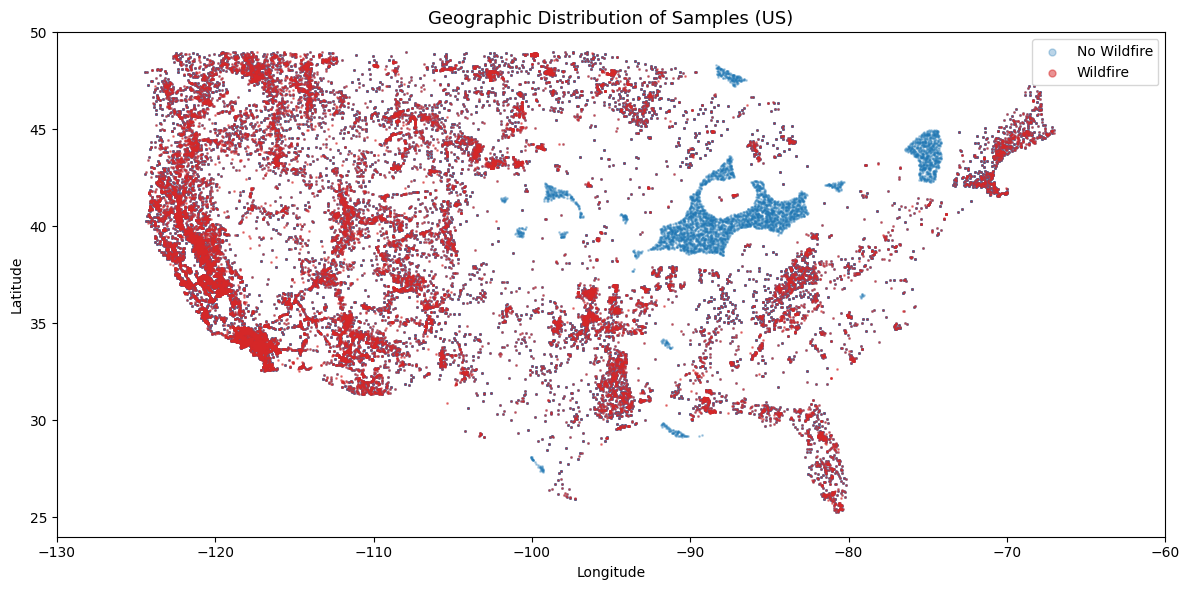

In [12]:
fire_samples = samples[samples['Wildfire'] == 'Yes']
no_fire_samples = samples[samples['Wildfire'] == 'No']

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(
    no_fire_samples['longitude'], no_fire_samples['latitude'],
    s=1, alpha=0.3, color='#1f77b4', label='No Wildfire'
)
ax.scatter(
    fire_samples['longitude'], fire_samples['latitude'],
    s=1, alpha=0.5, color='#d62728', label='Wildfire'
)
ax.set_title('Geographic Distribution of Samples (US)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=5, fontsize=10)
ax.set_xlim(-130, -60)
ax.set_ylim(24, 50)
plt.tight_layout()
plt.savefig('artifacts/geographic_distribution.png', dpi=150)
plt.show()

### looking at the fire ignitions by the year chart 

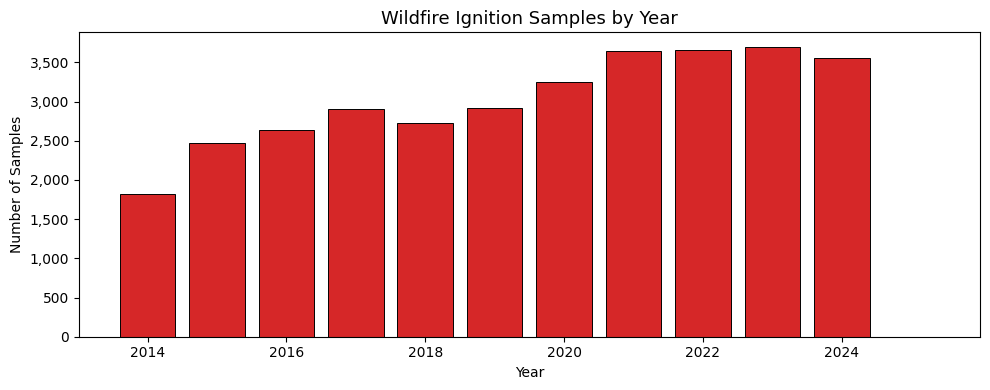

In [13]:
fire_samples = samples[samples['Wildfire'] == 'Yes'].copy()
fire_samples['year'] = pd.to_datetime(fire_samples['datetime']).dt.year
ignitions_by_year = fire_samples.groupby('year').size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ignitions_by_year.index, ignitions_by_year.values,
       color='#d62728', edgecolor='black', linewidth=0.7)
ax.set_title('Wildfire Ignition Samples by Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Samples')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('artifacts/ignitions_by_year.png', dpi=150)
plt.show()

### making a correlation matrix of the features

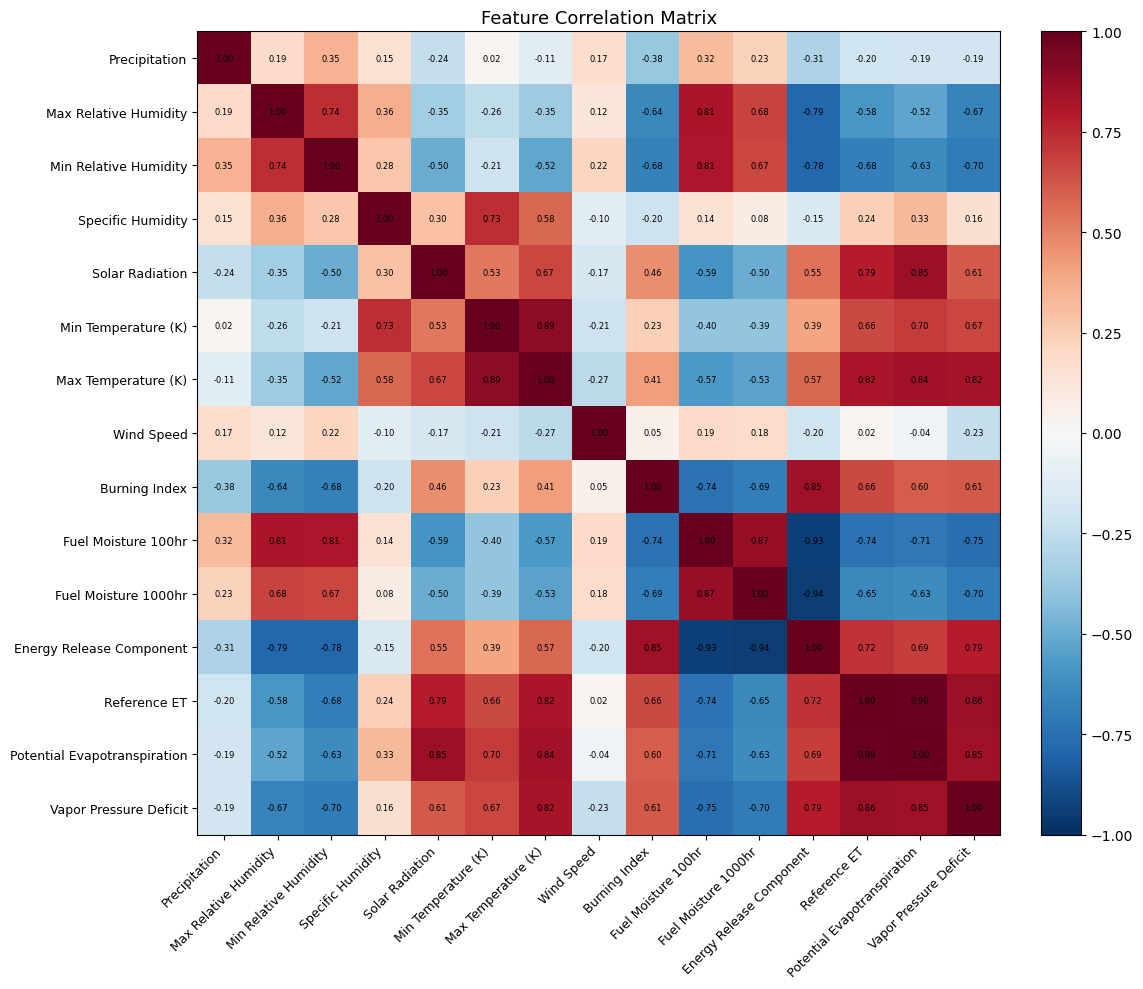

In [14]:
corr = df_plot[FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

labels = [FEATURE_LABELS[f] for f in FEATURES]
ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=6)

ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('artifacts/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()